# Telco Customer Churn — Data Preprocessing & Feature Engineering
### By Prajwol Manandhar - Data Engineer (Preprocessing & Feature Engineering)

This notebook covers the Data Engineer workflow across three stages:

1. **Load, audit & clean** the raw dataset
2. **Engineer & scale features** for downstream Clustering and ANN teams
3. **Validate (QA) & export handoff files**


## 0. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

RANDOM_STATE = 42
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

qa_log = []  # collects data-quality notes for the final QA report

def log(msg):
    print(msg)
    qa_log.append(msg)

pd.set_option("display.max_columns", None)


## 1. Upload the dataset
Run this cell to **choose files**.


In [ ]:
from google.colab import files

uploaded = files.upload()  # opens a file picker
INPUT_FILE = list(uploaded.keys())[0]
print(f"Loaded file: {INPUT_FILE}")


Saving Dataset_ATS_v2.csv to Dataset_ATS_v2.csv
Loaded file: Dataset_ATS_v2.csv


*(Alternative: if your file is already in Google Drive instead of your
local machine, comment out the cell above and use this instead:)*
```python
from google.colab import drive
drive.mount('/content/drive')
INPUT_FILE = "/content/drive/MyDrive/path/to/Dataset_ATS_v2.csv"
```


## Stage 1 — Load, Audit & Clean

- Load the raw file and inspect its shape/columns
- Check for missing values
- Trim whitespace formatting issues
- Check for exact duplicate rows (and decide how to handle them)
- Check for logical inconsistencies between related fields
- Encode categorical variables (binary + one-hot)


In [ ]:
df = pd.read_csv(INPUT_FILE)
log(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")
log(f"Columns: {list(df.columns)}")
df.head()


Loaded dataset: 7043 rows, 10 columns
Columns: ['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'MonthlyCharges', 'Churn']


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes
1,Male,0,No,41,Yes,No,DSL,One year,25,No
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No


In [ ]:
# --- Missing data audit -------------------------------------------------
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    log("Missing values: NONE found across any column.")
else:
    log(f"Missing values found:\n{missing}")
    for col in missing.index:
        if df[col].dtype in [np.int64, np.float64]:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])


Missing values: NONE found across any column.


In [ ]:
# --- Whitespace / formatting audit --------------------------------------
obj_cols = df.select_dtypes(include="object").columns.tolist()
for col in obj_cols:
    df[col] = df[col].astype(str).str.strip()
log(f"Trimmed whitespace on categorical columns: {obj_cols}")


Trimmed whitespace on categorical columns: ['gender', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'Churn']


In [ ]:
# --- Duplicate rows audit ------------------------------------------------
n_dupes = df.duplicated().sum()
log(f"Exact duplicate rows found: {n_dupes}")
log(
    "DECISION: Duplicates are NOT dropped. The dataset has no unique customer "
    "ID, and the feature space is small enough that exact-row collisions are "
    "statistically plausible for genuinely distinct customers. Without an ID "
    "column there is no way to confirm these are true duplicate records "
    "rather than coincidental matches, so removing them risks discarding "
    "real customers. Flagged as a data-collection limitation for the team."
)


Exact duplicate rows found: 302
DECISION: Duplicates are NOT dropped. The dataset has no unique customer ID, and the feature space is small enough that exact-row collisions are statistically plausible for genuinely distinct customers. Without an ID column there is no way to confirm these are true duplicate records rather than coincidental matches, so removing them risks discarding real customers. Flagged as a data-collection limitation for the team.


In [ ]:
# --- Logical consistency check: MultipleLines vs PhoneService ------------
# A customer without phone service cannot logically have multiple lines.
inconsistent_mask = (df["PhoneService"] == "No") & (df["MultipleLines"] == "Yes")
n_inconsistent = inconsistent_mask.sum()
log(
    f"Logical inconsistency found: {n_inconsistent} rows have "
    f"PhoneService='No' but MultipleLines='Yes' (impossible combination)."
)
log("DECISION: Recoding MultipleLines to 'No' wherever PhoneService is 'No'.")
df.loc[inconsistent_mask, "MultipleLines"] = "No"


Logical inconsistency found: 260 rows have PhoneService='No' but MultipleLines='Yes' (impossible combination).
DECISION: Recoding MultipleLines to 'No' wherever PhoneService is 'No'.


In [ ]:
# --- Range / sanity checks -----------------------------------------------
log(f"tenure range: {df.tenure.min()}-{df.tenure.max()} months")
log(f"tenure == 0 (new customers): {(df.tenure == 0).sum()} rows -- valid, kept as-is.")
log(f"MonthlyCharges range: {df.MonthlyCharges.min()}-{df.MonthlyCharges.max()}")


tenure range: 0-72 months
tenure == 0 (new customers): 11 rows -- valid, kept as-is.
MonthlyCharges range: 18-119


In [ ]:
# --- Encode binary categorical variables ----------------------------------
binary_maps = {
    "gender": {"Female": 0, "Male": 1},
    "Dependents": {"No": 0, "Yes": 1},
    "PhoneService": {"No": 0, "Yes": 1},
    "MultipleLines": {"No": 0, "Yes": 1},
    "InternetService": {"DSL": 0, "Fiber optic": 1},  # no 'No internet' case here
    "Churn": {"No": 0, "Yes": 1},
}
for col, mapping in binary_maps.items():
    df[col] = df[col].map(mapping)
log(f"Binary-encoded columns: {list(binary_maps.keys())}")


Binary-encoded columns: ['gender', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'Churn']


In [ ]:
# --- Encode multi-class categorical (Contract) ----------------------------
# One-hot encoding avoids imposing a false numeric distance between categories.
contract_dummies = pd.get_dummies(df["Contract"], prefix="Contract").astype(int)
df = pd.concat([df, contract_dummies], axis=1)
log(f"One-hot encoded 'Contract' into: {list(contract_dummies.columns)}")

log("Stage 1 complete: dataset cleaned and fully encoded.")
df.head()


One-hot encoded 'Contract' into: ['Contract_Month-to-month', 'Contract_One year', 'Contract_Two year']
Stage 1 complete: dataset cleaned and fully encoded.


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn,Contract_Month-to-month,Contract_One year,Contract_Two year
0,0,0,0,1,0,0,0,Month-to-month,25,1,1,0,0
1,1,0,0,41,1,0,0,One year,25,0,0,1,0
2,0,0,1,52,1,0,0,Month-to-month,19,0,1,0,0
3,0,0,0,1,1,0,0,One year,76,1,0,1,0
4,1,0,0,67,1,0,1,Month-to-month,51,0,1,0,0


## Stage 2 — Feature Engineering & Scaling

- Engineer new features that better expose churn-relevant signal
- Select the feature set for clustering
- Scale numeric features (StandardScaler) for distance-based clustering


In [ ]:
# Engineered feature 1: ContractMonths -- numeric commitment length
contract_months_map = {"Month-to-month": 0, "One year": 12, "Two year": 24}
df["ContractMonths"] = df["Contract"].map(contract_months_map)
log("Engineered 'ContractMonths': numeric commitment length (0/12/24).")

# Engineered feature 2: TenureYears
df["TenureYears"] = (df["tenure"] / 12).round(2)
log("Engineered 'TenureYears': tenure expressed in years.")


Engineered 'ContractMonths': numeric commitment length (0/12/24).
Engineered 'TenureYears': tenure expressed in years.


In [ ]:
# Engineered feature 3: TenureGroup (bucketed, for cluster interpretation)
bins = [-1, 12, 24, 48, 72]
labels = ["0-12mo", "13-24mo", "25-48mo", "49-72mo"]
df["TenureGroup"] = pd.cut(df["tenure"], bins=bins, labels=labels)
tenure_group_dummies = pd.get_dummies(df["TenureGroup"], prefix="TenureGroup").astype(int)
df = pd.concat([df, tenure_group_dummies], axis=1)
log("Engineered 'TenureGroup' (binned tenure) + one-hot dummies.")


Engineered 'TenureGroup' (binned tenure) + one-hot dummies.


In [ ]:
# Engineered feature 4: ServiceCount (phone + multiple lines add-ons)
df["ServiceCount"] = df["PhoneService"] + df["MultipleLines"]
log("Engineered 'ServiceCount': count of phone-related add-on services (0-2).")

# Engineered feature 5: MonthlyChargePerService (price-sensitivity proxy)
df["MonthlyChargePerService"] = df["MonthlyCharges"] / (df["ServiceCount"] + 1)
log("Engineered 'MonthlyChargePerService': spend normalised by service footprint.")


Engineered 'ServiceCount': count of phone-related add-on services (0-2).
Engineered 'MonthlyChargePerService': spend normalised by service footprint.


In [ ]:
# Feature selection for clustering
clustering_features = [
    "tenure", "MonthlyCharges", "ContractMonths", "ServiceCount",
    "MonthlyChargePerService", "InternetService", "SeniorCitizen", "Dependents",
]
log(f"Selected features for clustering: {clustering_features}")


Selected features for clustering: ['tenure', 'MonthlyCharges', 'ContractMonths', 'ServiceCount', 'MonthlyChargePerService', 'InternetService', 'SeniorCitizen', 'Dependents']


In [ ]:
# Feature scaling (for clustering)
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df[clustering_features])
df_clustering_scaled = pd.DataFrame(
    scaled_array, columns=[f"{c}_scaled" for c in clustering_features]
)
log(
    "Applied StandardScaler to clustering feature set (fit on full dataset -- "
    "appropriate for unsupervised clustering, no leakage concern since there "
    "is no predicted target)."
)
log("Stage 2 complete: features engineered and scaled.")
df_clustering_scaled.head()


Applied StandardScaler to clustering feature set (fit on full dataset -- appropriate for unsupervised clustering, no leakage concern since there is no predicted target).
Stage 2 complete: features engineered and scaled.


,tenure_scaled,MonthlyCharges_scaled,ContractMonths_scaled,ServiceCount_scaled,MonthlyChargePerService_scaled,InternetService_scaled,SeniorCitizen_scaled,Dependents_scaled
0,-1.277445,-1.321350,-0.828207,-2.039808,-0.347422,-0.885660,-0.439916,-0.654012
1,0.351370,-1.321350,0.371271,-0.456214,-1.202844,-0.885660,-0.439916,-0.654012
2,0.799294,-1.520755,-0.828207,-0.456214,-1.408146,-0.885660,-0.439916,1.529024
3,-1.277445,0.373593,0.371271,-0.456214,0.542217,-0.885660,-0.439916,-0.654012
4,1.410099,-0.457261,-0.828207,-0.456214,-0.313205,1.129102,-0.439916,-0.654012


## 2.5 Quick Exploratory Visualisations
A few sanity-check plots to support your data quality write-up.


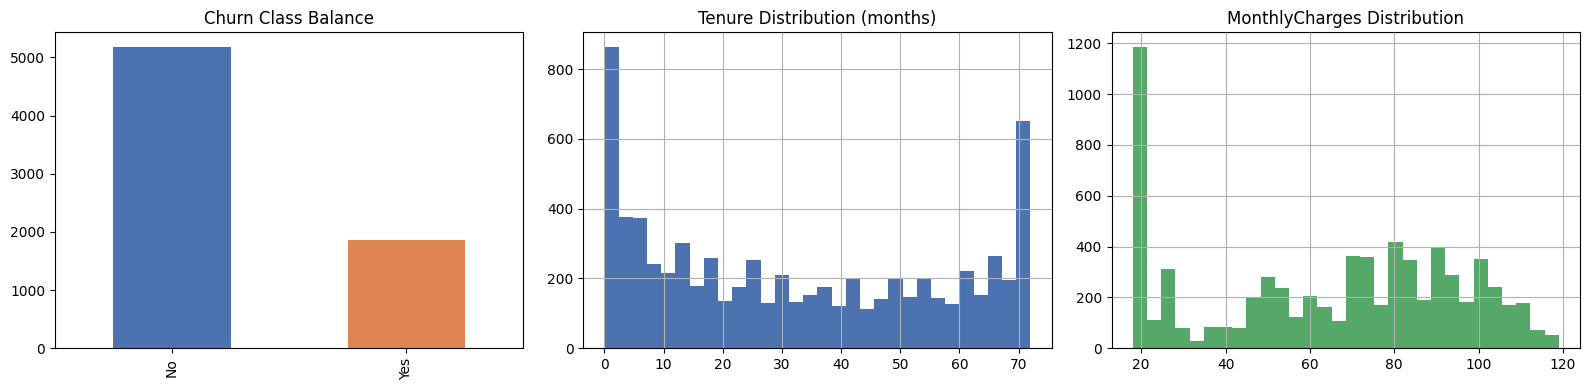

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df["Churn"].map({0: "No", 1: "Yes"}).value_counts().plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"]
)
axes[0].set_title("Churn Class Balance")
axes[0].set_xlabel("")

df["tenure"].hist(bins=30, ax=axes[1], color="#4C72B0")
axes[1].set_title("Tenure Distribution (months)")

df["MonthlyCharges"].hist(bins=30, ax=axes[2], color="#55A868")
axes[2].set_title("MonthlyCharges Distribution")

plt.tight_layout()
plt.show()


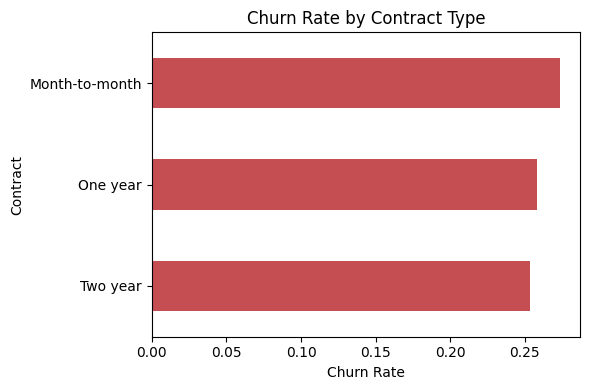

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
churn_by_contract = df.groupby("Contract")["Churn"].mean().sort_values()
churn_by_contract.plot(kind="barh", ax=ax, color="#C44E52")
ax.set_xlabel("Churn Rate")
ax.set_title("Churn Rate by Contract Type")
plt.tight_layout()
plt.show()


## Stage 3 — Validation, QA & Handoff

- Run integrity checks on the transformed data
- Note class balance for the ANN team
- Assemble and export the three handoff files
- Write out the QA / decision log


In [ ]:
# --- Post-transform integrity checks --------------------------------------
assert df.isnull().sum().sum() == 0, "Nulls introduced during transformation!"
log("QA check passed: no nulls present after transformation.")

assert (df["ServiceCount"] >= 0).all() and (df["ServiceCount"] <= 2).all()
log("QA check passed: ServiceCount within expected range [0, 2].")

assert set(df["Churn"].unique()) == {0, 1}
log("QA check passed: Churn target is binary (0/1).")

assert not ((df["PhoneService"] == 0) & (df["MultipleLines"] == 1)).any()
log("QA check passed: PhoneService/MultipleLines inconsistency resolved.")

for col in ["ContractMonths", "TenureYears", "MonthlyChargePerService"]:
    assert df[col].isnull().sum() == 0
log("QA check passed: all engineered features populated with no nulls.")


QA check passed: no nulls present after transformation.
QA check passed: ServiceCount within expected range [0, 2].
QA check passed: Churn target is binary (0/1).
QA check passed: PhoneService/MultipleLines inconsistency resolved.
QA check passed: all engineered features populated with no nulls.


In [ ]:
# --- Class balance note for the ANN team ----------------------------------
churn_rate = df["Churn"].mean()
log(
    f"Target class balance: Churn=Yes in {churn_rate:.1%} of rows "
    f"(Churn=No in {1 - churn_rate:.1%}). Mild imbalance -- recommend "
    "stratified train/test splitting and class weighting / threshold tuning."
)


Target class balance: Churn=Yes in 26.5% of rows (Churn=No in 73.5%). Mild imbalance -- recommend stratified train/test splitting and class weighting / threshold tuning.


In [ ]:
# --- (1) Master cleaned + encoded + engineered dataset --------------------
master_cols = [
    "gender", "SeniorCitizen", "Dependents", "tenure", "TenureYears", "TenureGroup",
    "PhoneService", "MultipleLines", "ServiceCount", "InternetService",
    "Contract", "ContractMonths",
    "Contract_Month-to-month", "Contract_One year", "Contract_Two year",
    "MonthlyCharges", "MonthlyChargePerService", "Churn",
]
df_master = df[master_cols]
df_master.to_csv(f"{OUTPUT_DIR}/telco_cleaned_encoded.csv", index=False)
log(f"Saved: {OUTPUT_DIR}/telco_cleaned_encoded.csv ({df_master.shape[0]} rows, {df_master.shape[1]} cols)")


Saved: outputs/telco_cleaned_encoded.csv (7043 rows, 18 cols)


In [ ]:
# --- (2) Clustering-ready scaled numeric feature set (no target) ----------
df_clustering_scaled.to_csv(f"{OUTPUT_DIR}/telco_clustering_ready_scaled.csv", index=False)
log(
    f"Saved: {OUTPUT_DIR}/telco_clustering_ready_scaled.csv "
    f"({df_clustering_scaled.shape[0]} rows, {df_clustering_scaled.shape[1]} cols)"
)


Saved: outputs/telco_clustering_ready_scaled.csv (7043 rows, 8 cols)


In [ ]:
# --- (3) ANN-ready feature set (encoded, UNSCALED, includes target) -------
# Scaling deliberately deferred: the ANN team should fit their scaler on the
# TRAIN split only (after their own train/test split) to avoid data leakage.
ann_feature_cols = [
    "gender", "SeniorCitizen", "Dependents", "tenure",
    "PhoneService", "MultipleLines", "ServiceCount", "InternetService",
    "Contract_Month-to-month", "Contract_One year", "Contract_Two year",
    "ContractMonths", "MonthlyCharges", "MonthlyChargePerService",
    "Churn",
]
df_ann = df[ann_feature_cols]
df_ann.to_csv(f"{OUTPUT_DIR}/telco_ann_ready.csv", index=False)
log(
    f"Saved: {OUTPUT_DIR}/telco_ann_ready.csv ({df_ann.shape[0]} rows, "
    f"{df_ann.shape[1]} cols). NOTE: left unscaled on purpose."
)


Saved: outputs/telco_ann_ready.csv (7043 rows, 15 cols). NOTE: left unscaled on purpose.


In [ ]:
# --- Write the QA / decision log -------------------------------------------
limitations = """
## Known Limitations & Challenges

- **No customer ID column** -- blocks definitive duplicate-record detection;
  302 duplicate rows were retained rather than dropped (see Stage 1).
- **No `TotalCharges` / account-value field** -- unlike the standard public
  Telco churn dataset, only `MonthlyCharges` is available, so lifetime-value
  and billing-consistency checks can't be derived.
- **Weak apparent relationship between tenure/spend and contract or internet
  type** -- distributions look nearly identical across groups, atypical of
  real telco behaviour. May indicate low signal or a partially synthetic
  extract; flagged so downstream model performance is calibrated accordingly.
- **Limited feature set (9 raw predictors)** -- no billing history, support
  tickets, or payment method, capping the achievable predictive ceiling.
- **Mild class imbalance** (26.5% churn) -- use stratified splits and
  F1/recall/ROC-AUC over raw accuracy for the ANN evaluation.
"""

with open(f"{OUTPUT_DIR}/data_quality_report.md", "w") as f:
    f.write("# Data Quality & Preprocessing Log\n\n")
    f.write("Generated by the Data Engineer preprocessing notebook.\n\n")
    for line in qa_log:
        f.write(f"- {line}\n")
    f.write(limitations)

log("Stage 3 complete: files validated and handed off.")
print("\nAll outputs written to ./outputs/")


Stage 3 complete: files validated and handed off.

All outputs written to ./outputs/


## 3. Download your outputs
View or download all four handoff files as a zip.

In [ ]:
display(df_ann)

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,ServiceCount,InternetService,Contract_Month-to-month,Contract_One year,Contract_Two year,ContractMonths,MonthlyCharges,MonthlyChargePerService,Churn
0,0,0,0,1,0,0,0,0,1,0,0,0,25,25.000000,1
1,1,0,0,41,1,0,1,0,0,1,0,12,25,12.500000,0
2,0,0,1,52,1,0,1,0,1,0,0,0,19,9.500000,0
3,0,0,0,1,1,0,1,0,0,1,0,12,76,38.000000,1
4,1,0,0,67,1,0,1,1,1,0,0,0,51,25.500000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,0,1,1,1,2,0,0,1,0,12,95,31.666667,1
7039,0,0,1,23,1,1,2,1,0,1,0,12,91,30.333333,0
7040,1,0,1,12,1,0,1,0,1,0,0,0,21,10.500000,0
7041,1,1,0,12,1,1,2,1,1,0,0,0,99,33.000000,1


In [ ]:
with open(f"{OUTPUT_DIR}/data_quality_report.md", "r") as f:
    report_content = f.read()
print(report_content)

# Data Quality & Preprocessing Log

Generated by the Data Engineer preprocessing notebook.

- Loaded dataset: 7043 rows, 10 columns
- Columns: ['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'MonthlyCharges', 'Churn']
- Missing values: NONE found across any column.
- Trimmed whitespace on categorical columns: ['gender', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'Churn']
- Exact duplicate rows found: 302
- DECISION: Duplicates are NOT dropped. The dataset has no unique customer ID, and the feature space is small enough that exact-row collisions are statistically plausible for genuinely distinct customers. Without an ID column there is no way to confirm these are true duplicate records rather than coincidental matches, so removing them risks discarding real customers. Flagged as a data-collection limitation for the team.
- Logical inconsistency found: 260 rows have PhoneService='No' bu

In [37]:
import shutil
from google.colab import files as colab_files

shutil.make_archive("telco_data_engineering_outputs", "zip", OUTPUT_DIR)
colab_files.download("telco_data_engineering_outputs.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Visualizing `df_ann`

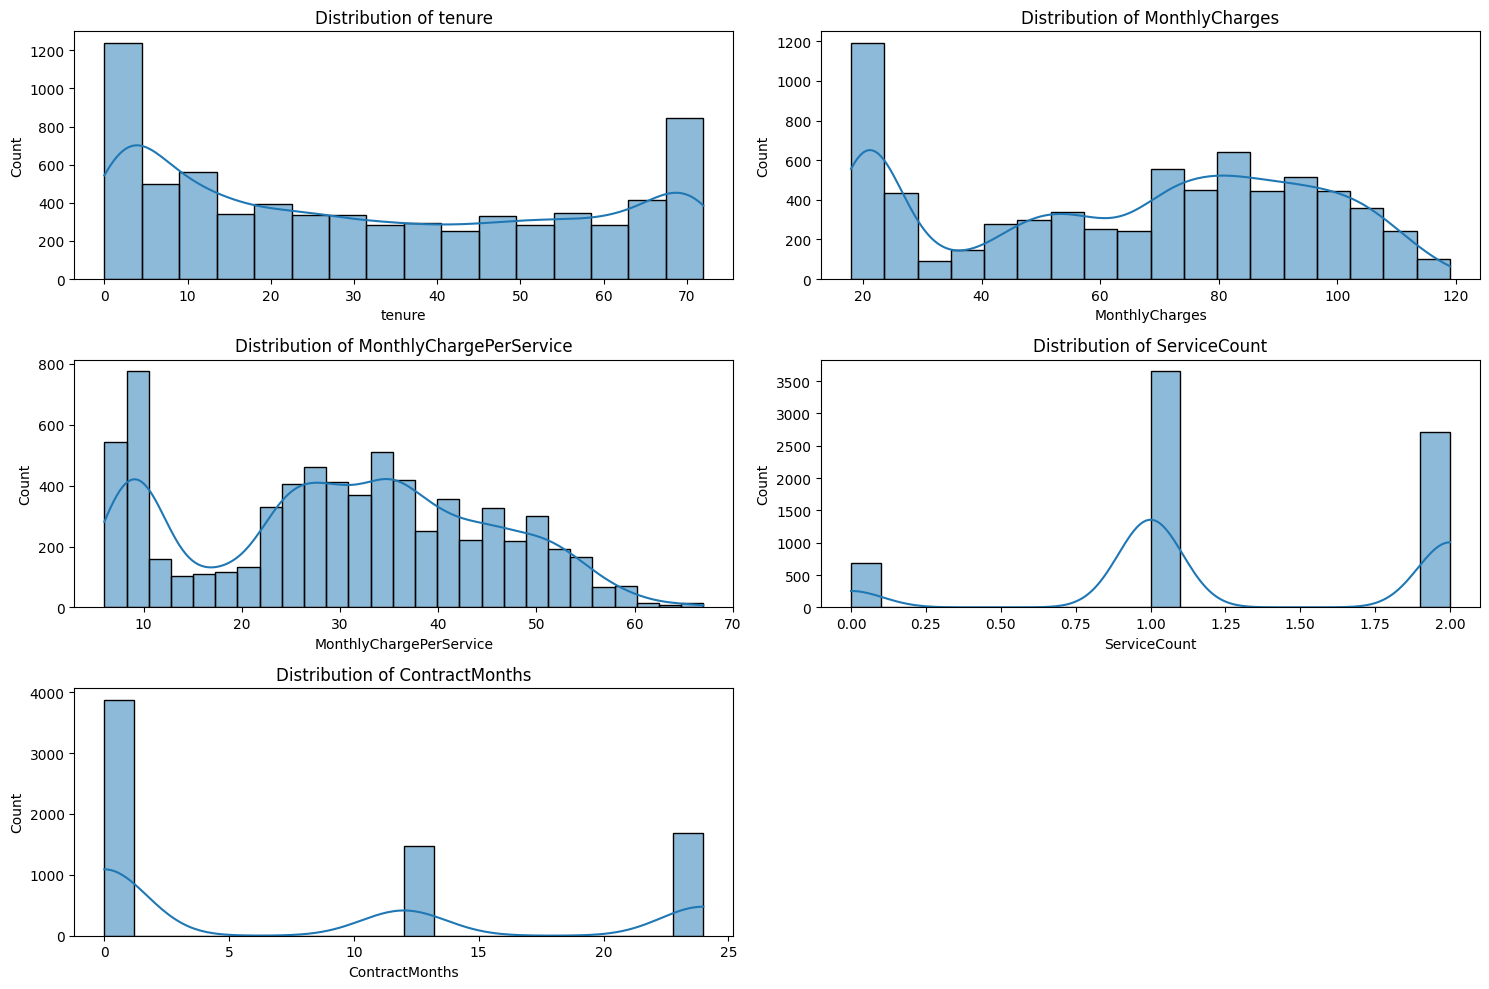

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical and categorical columns in df_ann
numerical_cols = [
    'tenure', 'MonthlyCharges', 'MonthlyChargePerService',
    'ServiceCount', 'ContractMonths'
]
categorical_cols = [
    'gender', 'SeniorCitizen', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'Contract_Month-to-month', 'Contract_One year',
    'Contract_Two year', 'Churn'
]

# --- Histograms for Numerical Features ---
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 2, i + 1)
    sns.histplot(df_ann[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

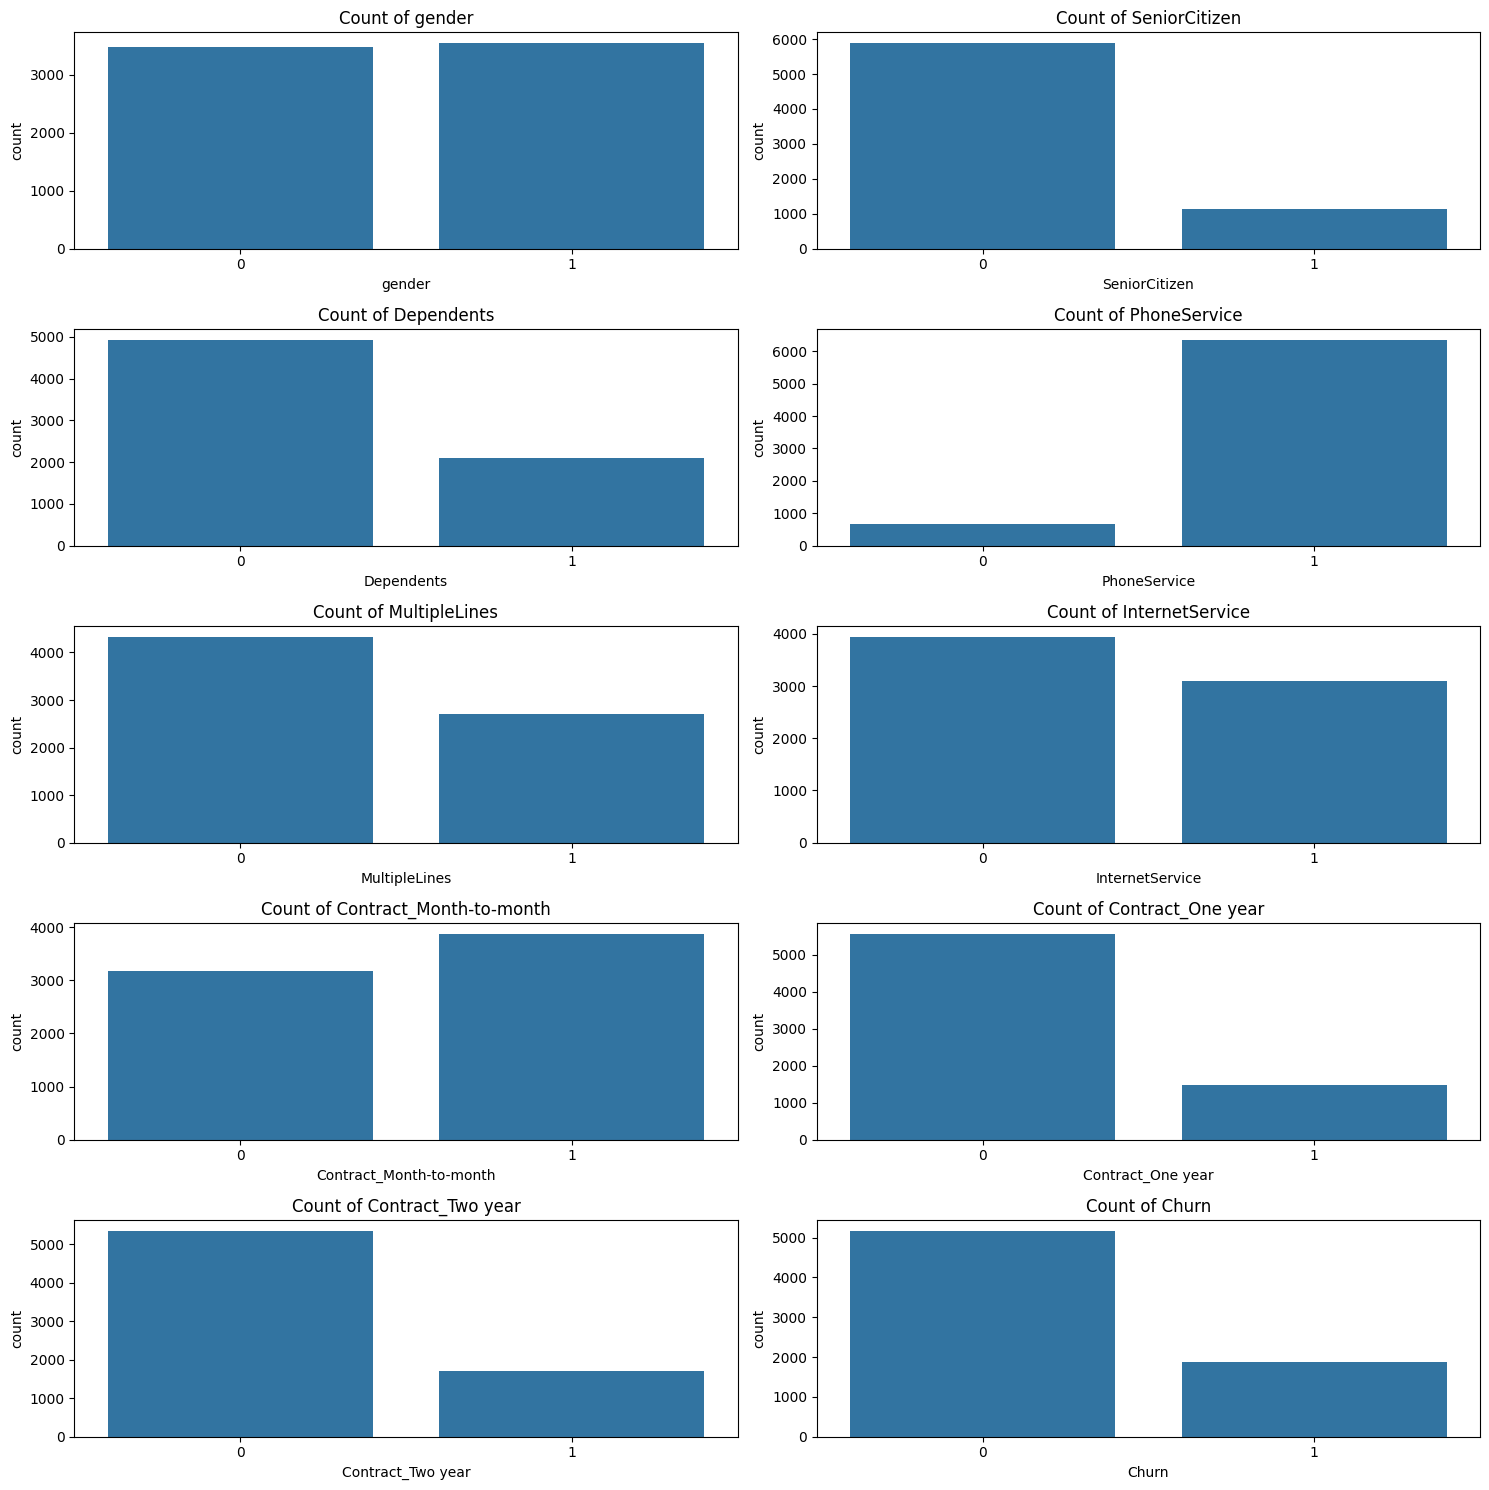

In [35]:
# --- Bar Plots for Categorical Features ---
plt.figure(figsize=(15, 15))
for i, col in enumerate(categorical_cols):
    plt.subplot(5, 2, i + 1)
    sns.countplot(x=col, data=df_ann)
    plt.title(f'Count of {col}')
plt.tight_layout()
plt.show()

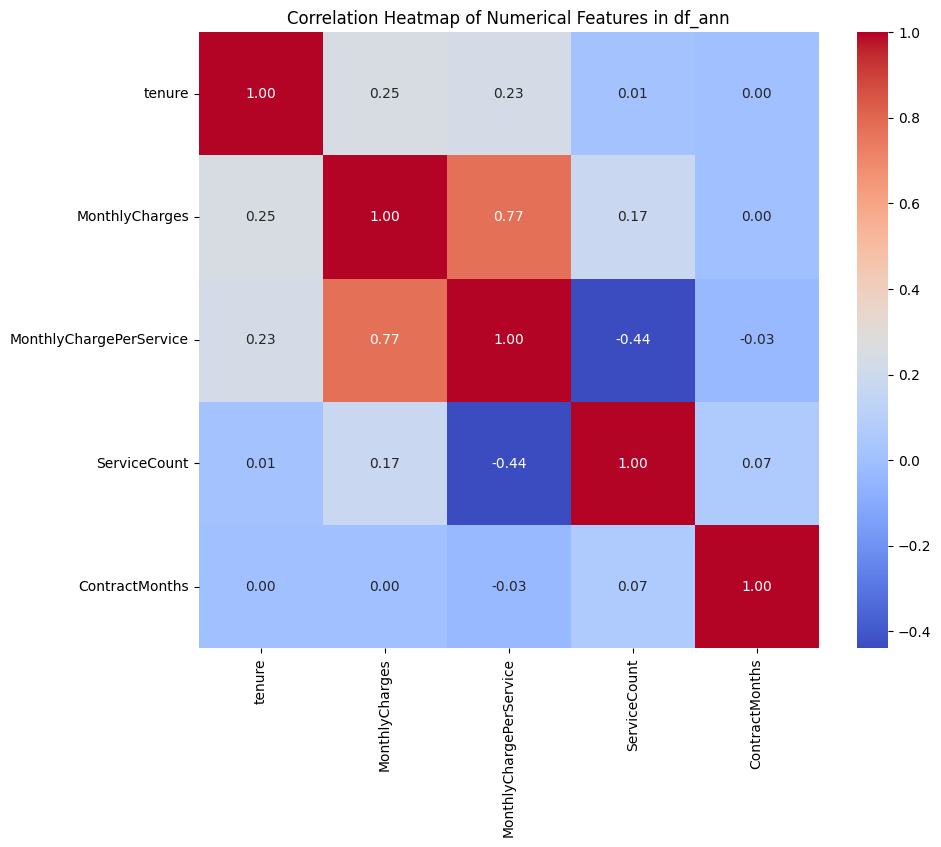

In [36]:
# --- Correlation Heatmap for Numerical Features ---
plt.figure(figsize=(10, 8))
sns.heatmap(df_ann[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features in df_ann')
plt.show()